In [1]:
# Importing Libraries


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Loading Dataset

In [4]:
DATA_PATH = "maize_market_1000.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")

print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (1000, 9)

First 5 rows:


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Maize,21.9,16.3,0.0,2398,0,1770
1,2023-01-02,Delhi,Maize,22.3,16.2,1.4,2469,0,1816
2,2023-01-03,Delhi,Maize,22.0,16.0,0.7,2494,0,1848
3,2023-01-04,Delhi,Maize,22.3,16.3,0.0,2545,0,1889
4,2023-01-05,Delhi,Maize,22.6,16.4,1.0,2598,0,1941



Columns:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [5]:
# Overview


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(1000, 9)

Data Types:
date                      str
location                  str
crop                      str
price_per_kg          float64
temperature_c         float64
rainfall_mm           float64
market_arrivals_kg      int64
festival_flag           int64
demand_kg               int64
dtype: object

Missing Values:
date                  0
location              0
crop                  0
price_per_kg          0
temperature_c         0
rainfall_mm           0
market_arrivals_kg    0
festival_flag         0
demand_kg             0
dtype: int64

Duplicate Rows:
0


In [7]:
# Convert Date

In [8]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

print("Date conversion completed.")

print("\nInvalid dates:")
print(df["date"].isnull().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

Date conversion completed.

Invalid dates:
0

Date range:
2023-01-01 00:00:00 to 2025-09-26 00:00:00


In [9]:
# Standarize Cols name

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns after standardization:")
print(df.columns.tolist())

Columns after standardization:
['date', 'location', 'crop', 'price_per_kg', 'temperature_c', 'rainfall_mm', 'market_arrivals_kg', 'festival_flag', 'demand_kg']


In [11]:
# Removing useless rows

In [12]:
before_rows = len(df)

df = df.dropna(
    subset=["date", "demand_kg"]
).copy()

df = df[
    (df["price_per_kg"] >= 0) &
    (df["rainfall_mm"] >= 0) &
    (df["market_arrivals_kg"] >= 0) &
    (df["demand_kg"] >= 0)
].copy()

df = df.drop_duplicates().copy()

after_rows = len(df)

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before cleaning: 1000
Rows after cleaning: 1000
Rows removed: 0


In [13]:
# Handling missing vals

In [14]:
numeric_columns = [
    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag"
]

categorical_columns = [
    "location",
    "crop"
]

for column in numeric_columns:

    df[column] = df[column].fillna(
        df[column].median()
    )

for column in categorical_columns:

    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

# Demand is the target.
# We don't fabricate missing target values.
df = df.dropna(
    subset=["demand_kg"]
).copy()

print("Remaining missing values:")
display(df.isnull().sum())

Remaining missing values:


date                  0
location              0
crop                  0
price_per_kg          0
temperature_c         0
rainfall_mm           0
market_arrivals_kg    0
festival_flag         0
demand_kg             0
dtype: int64

In [15]:
# Sort data chronologically

In [16]:
df = df.sort_values(
    by=[
        "location",
        "crop",
        "date"
    ]
).reset_index(drop=True)

print("Data sorted successfully.")

display(df.head())

Data sorted successfully.


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Maize,21.9,16.3,0.0,2398,0,1770
1,2023-01-02,Delhi,Maize,22.3,16.2,1.4,2469,0,1816
2,2023-01-03,Delhi,Maize,22.0,16.0,0.7,2494,0,1848
3,2023-01-04,Delhi,Maize,22.3,16.3,0.0,2545,0,1889
4,2023-01-05,Delhi,Maize,22.6,16.4,1.0,2598,0,1941


In [17]:
# Check Location and crop

In [18]:
df = df.sort_values(
    by=[
        "location",
        "crop",
        "date"
    ]
).reset_index(drop=True)

print("Data sorted successfully.")

display(df.head())

Data sorted successfully.


,date,location,crop,price_per_kg,temperature_c,rainfall_mm,market_arrivals_kg,festival_flag,demand_kg
0,2023-01-01,Delhi,Maize,21.9,16.3,0.0,2398,0,1770
1,2023-01-02,Delhi,Maize,22.3,16.2,1.4,2469,0,1816
2,2023-01-03,Delhi,Maize,22.0,16.0,0.7,2494,0,1848
3,2023-01-04,Delhi,Maize,22.3,16.3,0.0,2545,0,1889
4,2023-01-05,Delhi,Maize,22.6,16.4,1.0,2598,0,1941


In [19]:
# Calender Feature

In [20]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["day_of_year"] = df["date"].dt.dayofyear

df["week_of_year"] = (
    df["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

df["quarter"] = df["date"].dt.quarter

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print("Calendar features created.")

display(
    df[
        [
            "date",
            "year",
            "month",
            "day",
            "day_of_week",
            "day_of_year",
            "week_of_year",
            "quarter",
            "is_weekend"
        ]
    ].head()
)

Calendar features created.


,date,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend
0,2023-01-01,2023,1,1,6,1,52,1,1
1,2023-01-02,2023,1,2,0,2,1,1,0
2,2023-01-03,2023,1,3,1,3,1,1,0
3,2023-01-04,2023,1,4,2,4,1,1,0
4,2023-01-05,2023,1,5,3,5,1,1,0


In [21]:
# Cyclic Feature

In [22]:
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

print("Cyclical features created.")

Cyclical features created.


In [23]:
# CReating Lag

In [24]:
lag_values = [
    1,
    2,
    3,
    7,
    14,
    30
]

for lag in lag_values:

    df[f"lag_{lag}"] = (
        df.groupby(
            ["location", "crop"]
        )["demand_kg"]
        .shift(lag)
    )

print("Lag features created.")

display(
    df[
        [
            "date",
            "location",
            "crop",
            "demand_kg",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_7",
            "lag_14",
            "lag_30"
        ]
    ].head(35)
)

Lag features created.


,date,location,crop,demand_kg,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30
0,2023-01-01,Delhi,Maize,1770,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,Delhi,Maize,1816,1770.0,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,Delhi,Maize,1848,1816.0,1770.0,NaN,NaN,NaN,NaN
3,2023-01-04,Delhi,Maize,1889,1848.0,1816.0,1770.0,NaN,NaN,NaN
4,2023-01-05,Delhi,Maize,1941,1889.0,1848.0,1816.0,NaN,NaN,NaN
5,2023-01-06,Delhi,Maize,1948,1941.0,1889.0,1848.0,NaN,NaN,NaN
6,2023-01-07,Delhi,Maize,2018,1948.0,1941.0,1889.0,NaN,NaN,NaN
7,2023-01-08,Delhi,Maize,2063,2018.0,1948.0,1941.0,1770.0,NaN,NaN
8,2023-01-09,Delhi,Maize,2089,2063.0,2018.0,1948.0,1816.0,NaN,NaN
9,2023-01-10,Delhi,Maize,2311,2089.0,2063.0,2018.0,1848.0,NaN,NaN


In [ ]:
# Creating Roll

In [25]:
grouped_demand = (
    df.groupby(
        ["location", "crop"]
    )["demand_kg"]
)

df["rolling_mean_7"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=7
        )
        .mean()
    )
)

df["rolling_mean_14"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=14,
            min_periods=14
        )
        .mean()
    )
)

df["rolling_mean_30"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=30,
            min_periods=30
        )
        .mean()
    )
)

df["rolling_std_7"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=7,
            min_periods=7
        )
        .std()
    )
)

df["rolling_std_30"] = (
    grouped_demand
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=30,
            min_periods=30
        )
        .std()
    )
)

print("Rolling features created successfully.")

Rolling features created successfully.


In [26]:
# Check Feature NaN value

In [27]:
lag_rolling_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

print("Missing values in lag/rolling features:")

display(
    df[lag_rolling_columns].isnull().sum()
)

Missing values in lag/rolling features:


lag_1                9
lag_2               18
lag_3               27
lag_7               63
lag_14             126
lag_30             270
rolling_mean_7      63
rolling_mean_14    126
rolling_mean_30    270
rolling_std_7       63
rolling_std_30     270
dtype: int64

In [28]:
# Removing rows with less history

In [29]:
before_rows = len(df)

df_model = df.dropna(
    subset=lag_rolling_columns
).copy()

after_rows = len(df_model)

print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before: 1000
Rows after: 730
Rows removed: 270


In [30]:
# Global timesplit

In [31]:
df_model = df_model.sort_values(
    by="date"
).reset_index(drop=True)

print("Modeling dataset shape:")
print(df_model.shape)

print("\nDate range:")
print(
    df_model["date"].min(),
    "to",
    df_model["date"].max()
)

Modeling dataset shape:
(730, 32)

Date range:
2023-09-28 00:00:00 to 2025-09-26 00:00:00


In [37]:
# Defining some Features 


In [33]:
target_column = "demand_kg"

feature_columns = [
    "location",
    "crop",

    "price_per_kg",
    "temperature_c",
    "rainfall_mm",
    "market_arrivals_kg",
    "festival_flag",

    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "quarter",
    "is_weekend",

    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",

    "rolling_std_7",
    "rolling_std_30"
]

X = df_model[
    feature_columns
].copy()

y = df_model[
    target_column
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (730, 30)
y shape: (730,)


In [39]:
# Train-test split

# 70% → Training

# 15% → Validation

# 15% → Testing

In [35]:
n_rows = len(df_model)

train_end = int(
    n_rows * 0.70
)

validation_end = int(
    n_rows * 0.85
)


X_train = X.iloc[
    :train_end
].copy()

X_validation = X.iloc[
    train_end:validation_end
].copy()

X_test = X.iloc[
    validation_end:
].copy()


y_train = y.iloc[
    :train_end
].copy()

y_validation = y.iloc[
    train_end:validation_end
].copy()

y_test = y.iloc[
    validation_end:
].copy()


print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)


print("\nTraining period:")
print(
    df_model["date"].iloc[0],
    "to",
    df_model["date"].iloc[train_end - 1]
)

print("\nValidation period:")
print(
    df_model["date"].iloc[train_end],
    "to",
    df_model["date"].iloc[validation_end - 1]
)

print("\nTesting period:")
print(
    df_model["date"].iloc[validation_end],
    "to",
    df_model["date"].iloc[-1]
)

Training: (510, 30)
Validation: (110, 30)
Testing: (110, 30)

Training period:
2023-09-28 00:00:00 to 2025-02-18 00:00:00

Validation period:
2025-02-19 00:00:00 to 2025-06-08 00:00:00

Testing period:
2025-06-09 00:00:00 to 2025-09-26 00:00:00


In [40]:
# Creating Pipeline for automation

In [41]:
categorical_features = [
    "location",
    "crop"
]

numerical_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [43]:
# Evaluation Fxn

In [44]:
def safe_mape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs(
            (
                y_true[mask]
                -
                y_pred[mask]
            )
            /
            y_true[mask]
        )
    ) * 100


def evaluate_model(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = safe_mape(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }


print("Evaluation functions ready.")

Evaluation functions ready.


In [46]:
# Base line model (Base-Lag1)


In [47]:
baseline_train_pred = X_train[
    "lag_1"
].values

baseline_validation_pred = X_validation[
    "lag_1"
].values

baseline_test_pred = X_test[
    "lag_1"
].values


baseline_train_metrics = evaluate_model(
    y_train,
    baseline_train_pred
)

baseline_validation_metrics = evaluate_model(
    y_validation,
    baseline_validation_pred
)

baseline_test_metrics = evaluate_model(
    y_test,
    baseline_test_pred
)


print("Baseline Training:")
print(baseline_train_metrics)

print("\nBaseline Validation:")
print(baseline_validation_metrics)

print("\nBaseline Test:")
print(baseline_test_metrics)

Baseline Training:
{'MAE': 67.70588235294117, 'RMSE': np.float64(119.50574684680133), 'R2': 0.8879561186035367, 'MAPE': np.float64(5.941107332850854)}

Baseline Validation:
{'MAE': 66.52727272727273, 'RMSE': np.float64(117.16251339679661), 'R2': 0.8774564764468176, 'MAPE': np.float64(5.74361136772018)}

Baseline Test:
{'MAE': 71.83636363636364, 'RMSE': np.float64(129.42544361347754), 'R2': 0.9081279614306204, 'MAPE': np.float64(5.663324529639998)}


In [48]:
# Applying Linear Regression

In [49]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

print("Linear Regression pipeline created.")

Linear Regression pipeline created.


In [50]:
linear_model.fit(
    X_train,
    y_train
)

print(
    "Linear Regression training completed!"
)

Linear Regression training completed!


In [51]:
#Evaluate LInear Regression

In [54]:
lr_train_pred = linear_model.predict(
    X_train
)

lr_validation_pred = linear_model.predict(
    X_validation
)

lr_test_pred = linear_model.predict(
    X_test
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [55]:
lr_train_metrics = evaluate_model(
    y_train,
    lr_train_pred
)

lr_validation_metrics = evaluate_model(
    y_validation,
    lr_validation_pred
)

lr_test_metrics = evaluate_model(
    y_test,
    lr_test_pred
)


print("Linear Regression - Training:")
print(lr_train_metrics)

print("\nLinear Regression - Validation:")
print(lr_validation_metrics)

print("\nLinear Regression - Test:")
print(lr_test_metrics)

Linear Regression - Training:
{'MAE': 8.461715347571724, 'RMSE': np.float64(11.068411127157281), 'R2': 0.99903887222233, 'MAPE': np.float64(0.707799348422112)}

Linear Regression - Validation:
{'MAE': 8.880518554199762, 'RMSE': np.float64(12.286004014047446), 'R2': 0.9986524828226633, 'MAPE': np.float64(0.7221359061302913)}

Linear Regression - Test:
{'MAE': 11.14886100568228, 'RMSE': np.float64(15.847146948149565), 'R2': 0.9986226440201498, 'MAPE': np.float64(0.8634341459849494)}


In [56]:
#Applying XG Boost

In [57]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            XGBRegressor(

                n_estimators=300,

                learning_rate=0.05,

                max_depth=4,

                min_child_weight=5,

                subsample=0.8,

                colsample_bytree=0.8,

                reg_alpha=0.1,

                reg_lambda=1.0,

                random_state=RANDOM_STATE,

                objective="reg:squarederror",

                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created.")


XGBoost pipeline created.


In [58]:
xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost training completed!"
)

XGBoost training completed!


In [59]:
# XG Boost Evaluation

In [60]:
xgb_train_pred = xgb_model.predict(
    X_train
)

xgb_validation_pred = xgb_model.predict(
    X_validation
)

xgb_test_pred = xgb_model.predict(
    X_test
)

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [61]:
xgb_train_pred = xgb_model.predict(
    X_train
)

xgb_validation_pred = xgb_model.predict(
    X_validation
)

xgb_test_pred = xgb_model.predict(
    X_test
)

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [73]:
xgb_train_metrics = evaluate_model(
    y_train,
    xgb_train_pred
)

xgb_validation_metrics = evaluate_model(
    y_validation,
    xgb_validation_pred
)

xgb_test_metrics = evaluate_model(
    y_test,
    xgb_test_pred
)


print("XGBoost - Training:")
print(xgb_train_metrics)

print("\nXGBoost - Validation:")
print(xgb_validation_metrics)

print("\nXGBoost - Test:")
print(xgb_test_metrics)

XGBoost - Training:
{'MAE': 4.575996398925781, 'RMSE': np.float64(5.751572103785109), 'R2': 0.999740481376648, 'MAPE': np.float64(0.4072783229105609)}

XGBoost - Validation:
{'MAE': 11.53387451171875, 'RMSE': np.float64(14.936247577595209), 'R2': 0.9980084300041199, 'MAPE': np.float64(0.9381158494877182)}

XGBoost - Test:
{'MAE': 13.30105209350586, 'RMSE': np.float64(19.257652446089452), 'R2': 0.9979659914970398, 'MAPE': np.float64(0.9851272871781903)}


In [62]:
# Time series split

In [63]:
tscv = TimeSeriesSplit(
    n_splits=5
)

print(
    "TimeSeriesSplit created with 5 folds."
)

TimeSeriesSplit created with 5 folds.


In [64]:
# LR cross validation

In [65]:
lr_cv_results = []


for fold, (
    train_index,
    validation_index
) in enumerate(
    tscv.split(X_train),
    start=1
):

    X_fold_train = X_train.iloc[
        train_index
    ]

    X_fold_validation = X_train.iloc[
        validation_index
    ]

    y_fold_train = y_train.iloc[
        train_index
    ]

    y_fold_validation = y_train.iloc[
        validation_index
    ]


    fold_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                LinearRegression()
            )
        ]
    )


    fold_model.fit(
        X_fold_train,
        y_fold_train
    )


    fold_prediction = fold_model.predict(
        X_fold_validation
    )


    metrics = evaluate_model(
        y_fold_validation,
        fold_prediction
    )


    metrics["Fold"] = fold

    lr_cv_results.append(
        metrics
    )


lr_cv_df = pd.DataFrame(
    lr_cv_results
)

display(lr_cv_df)


print("\nAverage Linear Regression CV:")
display(
    lr_cv_df[
        [
            "MAE",
            "RMSE",
            "R2"
        ]
    ].mean()
)

,MAE,RMSE,R2,MAPE,Fold
0,326.083299,341.735304,0.064934,29.874736,1
1,20.159659,24.284700,0.995413,1.796106,2
2,12.811543,16.325049,0.997963,1.093214,3
3,9.807489,12.590458,0.998757,0.842503,4
4,8.725726,12.277056,0.998786,0.692518,5



Average Linear Regression CV:


MAE     75.517543
RMSE    81.442513
R2       0.811171
dtype: float64

In [66]:
# XG Boost cross val

In [67]:
xgb_cv_results = []


for fold, (
    train_index,
    validation_index
) in enumerate(
    tscv.split(X_train),
    start=1
):

    X_fold_train = X_train.iloc[
        train_index
    ]

    X_fold_validation = X_train.iloc[
        validation_index
    ]

    y_fold_train = y_train.iloc[
        train_index
    ]

    y_fold_validation = y_train.iloc[
        validation_index
    ]


    fold_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",

                XGBRegressor(

                    n_estimators=300,

                    learning_rate=0.05,

                    max_depth=4,

                    min_child_weight=5,

                    subsample=0.8,

                    colsample_bytree=0.8,

                    reg_alpha=0.1,

                    reg_lambda=1.0,

                    random_state=RANDOM_STATE,

                    objective="reg:squarederror",

                    n_jobs=-1
                )
            )
        ]
    )


    fold_model.fit(
        X_fold_train,
        y_fold_train
    )


    fold_prediction = fold_model.predict(
        X_fold_validation
    )


    metrics = evaluate_model(
        y_fold_validation,
        fold_prediction
    )


    metrics["Fold"] = fold

    xgb_cv_results.append(
        metrics
    )


xgb_cv_df = pd.DataFrame(
    xgb_cv_results
)

display(xgb_cv_df)


print("\nAverage XGBoost CV:")
display(
    xgb_cv_df[
        [
            "MAE",
            "RMSE",
            "R2"
        ]
    ].mean()
)

,MAE,RMSE,R2,MAPE,Fold
0,127.021309,135.320843,0.853380,11.832498,1
1,16.899702,22.491608,0.996065,1.376420,2
2,14.650837,20.751699,0.996709,1.149650,3
3,13.207512,23.027420,0.995843,1.044769,4
4,17.013988,24.430823,0.995191,1.307998,5



Average XGBoost CV:


MAE     37.758670
RMSE    45.204479
R2       0.967438
dtype: float64

In [68]:
# XG Boost vs LR

In [74]:
comparison_df = pd.DataFrame(
    [
        {
            "Model": "Baseline",

            "CV MAE": np.nan,

            "CV RMSE": np.nan,

            "CV R2": np.nan,

            "Validation MAE":
                baseline_validation_metrics["MAE"],

            "Validation RMSE":
                baseline_validation_metrics["RMSE"],

            "Validation R2":
                baseline_validation_metrics["R2"],

            "Test MAE":
                baseline_test_metrics["MAE"],

            "Test RMSE":
                baseline_test_metrics["RMSE"],

            "Test R2":
                baseline_test_metrics["R2"]
        },


        {
            "Model": "Linear Regression",

            "CV MAE":
                lr_cv_df["MAE"].mean(),

            "CV RMSE":
                lr_cv_df["RMSE"].mean(),

            "CV R2":
                lr_cv_df["R2"].mean(),

            "Validation MAE":
                lr_validation_metrics["MAE"],

            "Validation RMSE":
                lr_validation_metrics["RMSE"],

            "Validation R2":
                lr_validation_metrics["R2"],

            "Test MAE":
                lr_test_metrics["MAE"],

            "Test RMSE":
                lr_test_metrics["RMSE"],

            "Test R2":
                lr_test_metrics["R2"]
        },


        {
            "Model": "XGBoost",

            "CV MAE":
                xgb_cv_df["MAE"].mean(),

            "CV RMSE":
                xgb_cv_df["RMSE"].mean(),

            "CV R2":
                xgb_cv_df["R2"].mean(),

            "Validation MAE":
                xgb_validation_metrics["MAE"],

            "Validation RMSE":
                xgb_validation_metrics["RMSE"],

            "Validation R2":
                xgb_validation_metrics["R2"],

            "Test MAE":
                xgb_test_metrics["MAE"],

            "Test RMSE":
                xgb_test_metrics["RMSE"],

            "Test R2":
                xgb_test_metrics["R2"]
        }
    ]
)


comparison_df = comparison_df.sort_values(
    by="Validation RMSE"
).reset_index(
    drop=True
)


display(comparison_df)

,Model,CV MAE,CV RMSE,CV R2,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,75.517543,81.442513,0.811171,8.880519,12.286004,0.998652,11.148861,15.847147,0.998623
1,XGBoost,37.758670,45.204479,0.967438,11.533875,14.936248,0.998008,13.301052,19.257652,0.997966
2,Baseline,NaN,NaN,NaN,66.527273,117.162513,0.877456,71.836364,129.425444,0.908128


In [75]:
# Picking best model

In [76]:
best_model_name = comparison_df.iloc[
    0
]["Model"]

print(
    "Best Model:",
    best_model_name
)

Best Model: Linear Regression


In [77]:
# Overfit Check

In [78]:
overfitting_df = pd.DataFrame(
    [
        {
            "Model": "Linear Regression",

            "Train RMSE":
                lr_train_metrics["RMSE"],

            "Validation RMSE":
                lr_validation_metrics["RMSE"],

            "Test RMSE":
                lr_test_metrics["RMSE"]
        },

        {
            "Model": "XGBoost",

            "Train RMSE":
                xgb_train_metrics["RMSE"],

            "Validation RMSE":
                xgb_validation_metrics["RMSE"],

            "Test RMSE":
                xgb_test_metrics["RMSE"]
        }
    ]
)

display(
    overfitting_df
)

,Model,Train RMSE,Validation RMSE,Test RMSE
0,Linear Regression,11.068411,12.286004,15.847147
1,XGBoost,5.751572,14.936248,19.257652


In [79]:
# Selecting final Model

In [80]:
if best_model_name == "Linear Regression":

    selected_model = linear_model

    selected_test_prediction = (
        lr_test_pred
    )

elif best_model_name == "XGBoost":

    selected_model = xgb_model

    selected_test_prediction = (
        xgb_test_pred
    )

else:

    selected_model = None

    selected_test_prediction = (
        baseline_test_pred
    )


print(
    "Selected final model:",
    best_model_name
)

Selected final model: Linear Regression


In [81]:
# Actual vs Predicted

In [82]:
test_results = pd.DataFrame(
    {
        "date": df_model[
            "date"
        ].iloc[
            validation_end:
        ].values,

        "actual_demand": y_test.values,

        "predicted_demand":
            selected_test_prediction
    }
)

test_results = test_results.sort_values(
    "date"
)

display(
    test_results.head()
)

,date,actual_demand,predicted_demand
0,2025-06-09,842,822.594473
1,2025-06-10,862,853.470869
2,2025-06-11,877,872.658614
3,2025-06-12,907,895.367020
4,2025-06-13,909,901.781436


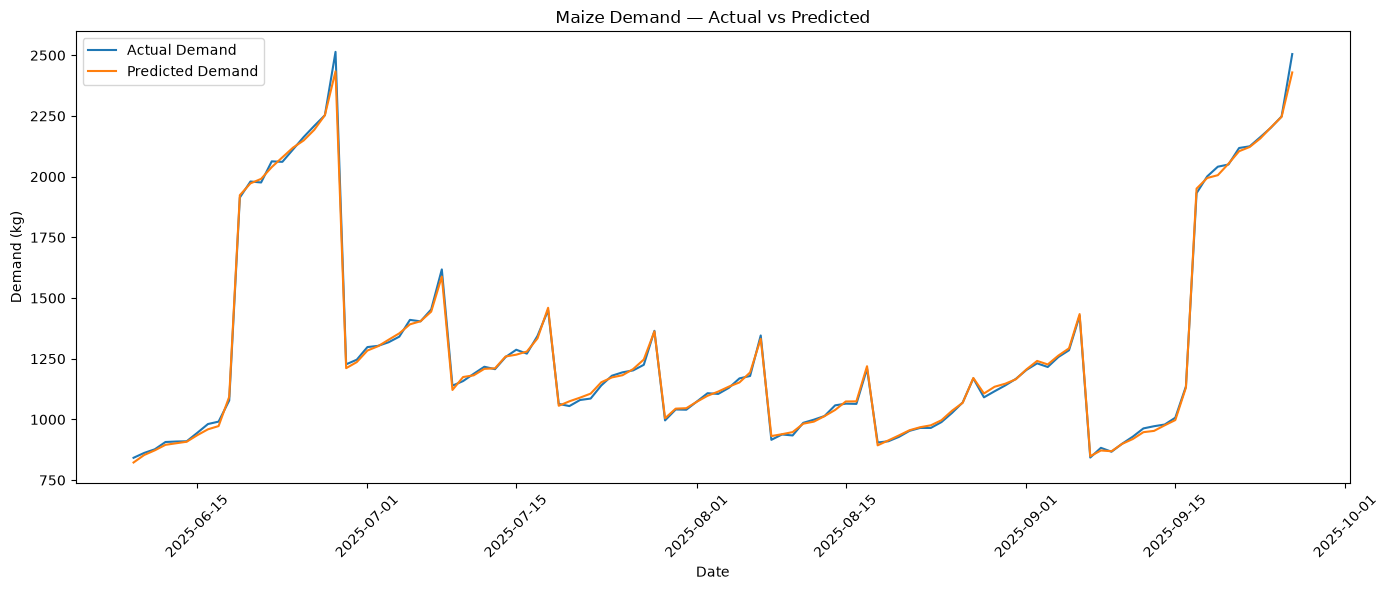

In [83]:
daily_results = (
    test_results
    .groupby("date")
    [
        [
            "actual_demand",
            "predicted_demand"
        ]
    ]
    .mean()
    .reset_index()
)


plt.figure(
    figsize=(14, 6)
)

plt.plot(
    daily_results["date"],
    daily_results["actual_demand"],
    label="Actual Demand"
)

plt.plot(
    daily_results["date"],
    daily_results["predicted_demand"],
    label="Predicted Demand"
)

plt.title(
    "Maize Demand — Actual vs Predicted"
)

plt.xlabel("Date")

plt.ylabel("Demand (kg)")

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

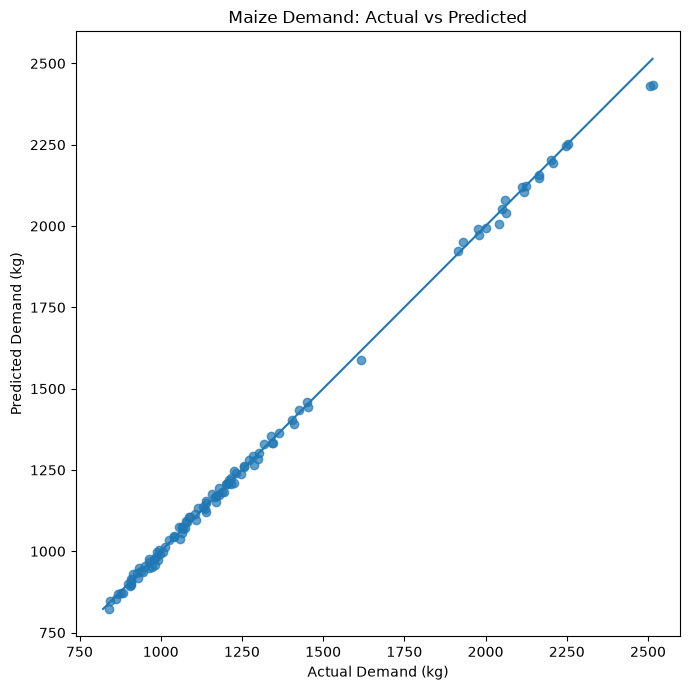

In [84]:
plt.figure(
    figsize=(7, 7)
)

plt.scatter(
    y_test,
    selected_test_prediction,
    alpha=0.7
)

minimum_value = min(
    y_test.min(),
    selected_test_prediction.min()
)

maximum_value = max(
    y_test.max(),
    selected_test_prediction.max()
)

plt.plot(
    [
        minimum_value,
        maximum_value
    ],

    [
        minimum_value,
        maximum_value
    ]
)

plt.title(
    "Maize Demand: Actual vs Predicted"
)

plt.xlabel(
    "Actual Demand (kg)"
)

plt.ylabel(
    "Predicted Demand (kg)"
)

plt.tight_layout()

plt.show()

In [85]:
# Error analysis

In [86]:
error_df = pd.DataFrame(
    {
        "date": df_model[
            "date"
        ].iloc[
            validation_end:
        ].values,

        "actual": y_test.values,

        "predicted":
            selected_test_prediction
    }
)


error_df["error"] = (
    error_df["actual"]
    -
    error_df["predicted"]
)

error_df["absolute_error"] = (
    error_df["error"].abs()
)

error_df["percentage_error"] = np.where(

    error_df["actual"] != 0,

    (
        error_df["absolute_error"]
        /
        error_df["actual"]
    ) * 100,

    np.nan
)


display(
    error_df.head()
)

,date,actual,predicted,error,absolute_error,percentage_error
0,2025-06-09,842,822.594473,19.405527,19.405527,2.304694
1,2025-06-10,862,853.470869,8.529131,8.529131,0.989458
2,2025-06-11,877,872.658614,4.341386,4.341386,0.495027
3,2025-06-12,907,895.367020,11.632980,11.632980,1.282578
4,2025-06-13,909,901.781436,7.218564,7.218564,0.794121


In [87]:
# Residual Distribution

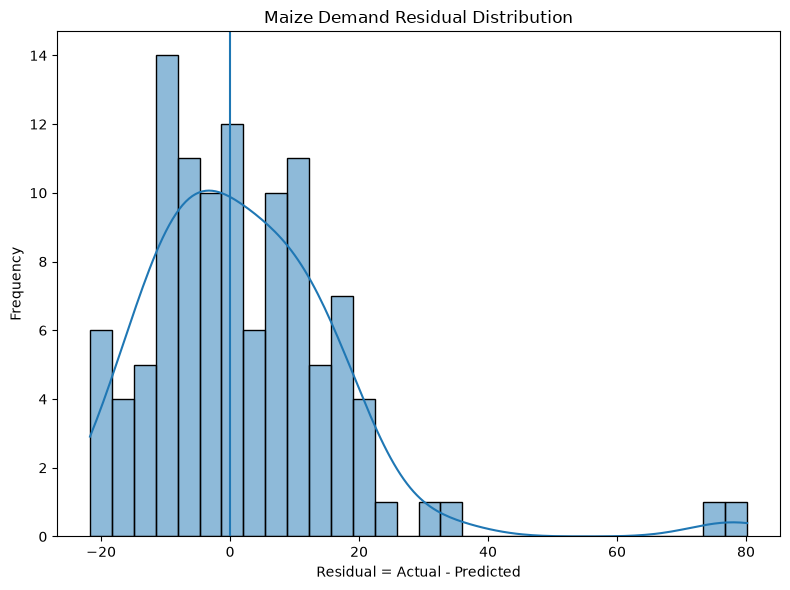

In [88]:
plt.figure(
    figsize=(8, 6)
)

sns.histplot(
    error_df["error"],
    kde=True,
    bins=30
)

plt.axvline(
    0
)

plt.title(
    "Maize Demand Residual Distribution"
)

plt.xlabel(
    "Residual = Actual - Predicted"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

In [89]:
# Retraining the LR again 

In [90]:
X_final_train = pd.concat(
    [
        X_train,
        X_validation
    ]
)

y_final_train = pd.concat(
    [
        y_train,
        y_validation
    ]
)


if best_model_name == "Linear Regression":

    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                LinearRegression()
            )
        ]
    )


elif best_model_name == "XGBoost":

    final_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",

                XGBRegressor(

                    n_estimators=300,

                    learning_rate=0.05,

                    max_depth=4,

                    min_child_weight=5,

                    subsample=0.8,

                    colsample_bytree=0.8,

                    reg_alpha=0.1,

                    reg_lambda=1.0,

                    random_state=RANDOM_STATE,

                    objective="reg:squarederror",

                    n_jobs=-1
                )
            )
        ]
    )


final_model.fit(
    X_final_train,
    y_final_train
)

print(
    "Final model trained successfully!"
)

print(
    "Training rows used:",
    len(X_final_train)
)

Final model trained successfully!
Training rows used: 620


In [91]:
# Retrained model cross val

In [92]:
final_test_prediction = final_model.predict(
    X_test
)

final_metrics = evaluate_model(
    y_test,
    final_test_prediction
)

print(
    "FINAL TEST PERFORMANCE"
)

print(
    "MAE:",
    round(
        final_metrics["MAE"],
        2
    )
)

print(
    "RMSE:",
    round(
        final_metrics["RMSE"],
        2
    )
)

print(
    "R²:",
    round(
        final_metrics["R2"],
        4
    )
)

print(
    "MAPE:",
    round(
        final_metrics["MAPE"],
        2
    ),
    "%"
)

FINAL TEST PERFORMANCE
MAE: 10.81
RMSE: 14.99
R²: 0.9988
MAPE: 0.84 %


In [100]:
# Saving the final model

In [101]:
MODEL_PATH = (
    "maize_demand_forecasting_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Model saved successfully!"
)

print(
    "File:",
    MODEL_PATH
)

Model saved successfully!
File: maize_demand_forecasting_model.joblib


In [102]:
FEATURE_PATH = (
    "maize_feature_columns.joblib"
)

joblib.dump(
    feature_columns,
    FEATURE_PATH
)

print(
    "Feature columns saved successfully!"
)

Feature columns saved successfully!


In [103]:
loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Saved Maize demand model loaded successfully!"
)

print(
    "Model type:",
    type(loaded_model)
)

Saved Maize demand model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>


In [104]:
# Test summary

In [107]:


print("MAIZE DEMAND FORECASTING — TRAINING SUMMARY")



print(
    "Dataset rows:",
    len(df)
)

print(
    "Modeling rows:",
    len(df_model)
)

print(
    "Locations:",
    df["location"].nunique()
)

print(
    "Crop:",
    df["crop"].unique()
)

print(
    "Best Model:",
    best_model_name
)

print(
    "Final Test MAE:",
    round(
        final_metrics["MAE"],
        2
    )
)

print(
    "Final Test RMSE:",
    round(
        final_metrics["RMSE"],
        2
    )
)

print(
    "Final Test R²:",
    round(
        final_metrics["R2"],
        4
    )
)

print(
    "Final Test MAPE:",
    round(
        final_metrics["MAPE"],
        2
    ),
    "%"
)



print(
    "Saved model:",
    MODEL_PATH
)

print(
    "Saved features:",
    FEATURE_PATH
)


MAIZE DEMAND FORECASTING — TRAINING SUMMARY
Dataset rows: 1000
Modeling rows: 730
Locations: 9
Crop: <ArrowStringArray>
['Maize']
Length: 1, dtype: str
Best Model: Linear Regression
Final Test MAE: 10.81
Final Test RMSE: 14.99
Final Test R²: 0.9988
Final Test MAPE: 0.84 %
Saved model: maize_demand_forecasting_model.joblib
Saved features: maize_feature_columns.joblib
